X的形状为: (300, 2)
X.shape[0]的值为: 300
质心集合形状为: (3, 2)
最近质心索引idx的形状为: (300,)
前三个元素的最近质心索引为: [0 2 1]
All tests passed!
计算得到的质心为: [[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]
All tests passed!
K-Means迭代 0/9
K-Means迭代 1/9
K-Means迭代 2/9
K-Means迭代 3/9
K-Means迭代 4/9
K-Means迭代 5/9
K-Means迭代 6/9
K-Means迭代 7/9
K-Means迭代 8/9
K-Means迭代 9/9
原始图像的形状为: (128, 128, 3)
K-Means迭代 0/9
K-Means迭代 1/9
K-Means迭代 2/9
K-Means迭代 3/9
K-Means迭代 4/9
K-Means迭代 5/9
K-Means迭代 6/9
K-Means迭代 7/9
K-Means迭代 8/9
K-Means迭代 9/9


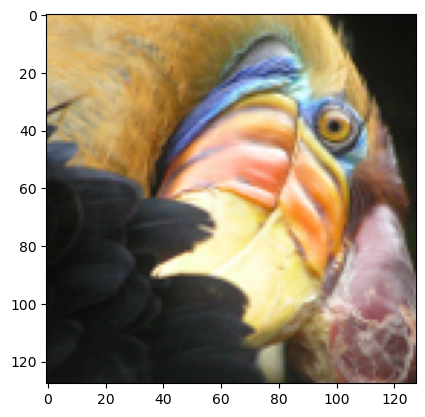

idx的形状: (16384,)
前五个像素的最近质心: [3 6 6 3 3]


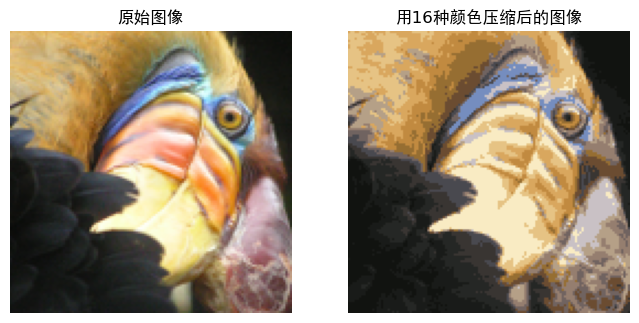

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *  # 该模块包含数据加载和绘图辅助函数

%matplotlib inline

# 设置中文字体
plt.rcParams["font.family"] = ["sans-serif","SimHei"]
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号
def find_closest_centroids(X, centroids):
    """
    计算每个样本所属的最近质心
    
    参数:
        X (ndarray): (m, n) 输入数据，m个样本，每个样本n个特征    
        centroids (ndarray): (k, n) k个质心的坐标
    
    返回:
        idx (array_like): (m,) 每个样本对应的最近质心的索引
    """

    # 设置质心数量
    K = centroids.shape[0]

    # 初始化返回结果
    idx = np.zeros(X.shape[0], dtype=int)

    ### 开始代码 ###
    # 遍历每个样本
    for i in range(X.shape[0]):
        # 计算当前样本到每个质心的距离
        distances = np.sqrt(np.sum((X[i] - centroids) ** 2, axis=1))
        # 找到距离最近的质心索引
        idx[i] = np.argmin(distances)
    ### 结束代码 ###
    
    return idx

# 加载数据
X = load_data()

# 选择初始质心（3个质心）
initial_centroids = np.array([[3,3], [6,2], [8,5]])

# 使用初始质心找到最近的质心
idx = find_closest_centroids(X, initial_centroids)
print("X的形状为:",X.shape)
print("X.shape[0]的值为:",X.shape[0])
print("质心集合形状为:",initial_centroids.shape)
print("最近质心索引idx的形状为:", idx.shape)
# 打印前三个样本的最近质心索引
print("前三个元素的最近质心索引为:", idx[:3])

# 单元测试
from public_tests import *
find_closest_centroids_test(find_closest_centroids)

def compute_centroids(X, idx, K):
    """
    根据每个质心所分配到的样本计算新的质心（取平均值）
    
    参数:
        X (ndarray):   (m, n) 输入数据点
        idx (ndarray): (m,) 每个样本对应的最近质心索引数组
        K (int):       质心/聚类的数量
    
    返回:
        centroids (ndarray): (K, n) 计算得到的新质心
    """
    
    # 有用的变量
    m, n = X.shape
    
    # 初始化返回结果
    centroids = np.zeros((K, n))
    
    ### 开始代码 ###
    # 遍历每个质心
    for k in range(K):
        # 找到分配给当前质心的所有样本
        #idx == k 是一个布尔数组（形状与idx相同），其中每个元素为True表示对应样本被分配给了第 k 个质心，False则表示没有。
        # 例如，若idx = [0,1,0,2]，则idx == 0的结果是[True, False, True, False]。
        samples = X[idx == k]  # samples.shape = (num_samples_assigned_to_k, n)
        # 计算这些样本的平均值作为新的质心
        centroids[k] = np.mean(samples, axis=0) #axis=0表示按列计算均值，即对每个特征计算均值
    ### 结束代码 ###
    
    return centroids

K = 3
centroids = compute_centroids(X, idx, K)

print("计算得到的质心为:", centroids)

# 单元测试
compute_centroids_test(compute_centroids)

def run_kMeans(X, initial_centroids, max_iters=10, plot_progress=False):
    """
    在数据矩阵X上运行K-Means算法，其中X的每一行是一个样本
    """
    
    # 初始化变量
    m, n = X.shape
    K = initial_centroids.shape[0]
    centroids = initial_centroids.copy()
    previous_centroids = centroids.copy()    
    idx = np.zeros(m)
    
    # 运行K-Means
    for i in range(max_iters):
        
        # 输出进度
        print(f"K-Means迭代 {i}/{max_iters-1}")
        
        # 为每个样本分配最近的质心
        idx = find_closest_centroids(X, centroids)
        
        # 可选：绘制进度
        # if plot_progress:
        #     plot_progress_kMeans(X, centroids, previous_centroids, idx, K, i)
        #     previous_centroids = centroids.copy()
            
        # 根据分配结果计算新的质心
        centroids = compute_centroids(X, idx, K)
    
    plt.show() 
    return centroids, idx

# 加载示例数据集
X = load_data()

# 设置初始质心
initial_centroids = np.array([[3,3],[6,2],[8,5]])
K = 3

# 迭代次数
max_iters = 10

# 运行K-Means算法
centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)

def kMeans_init_centroids(X, K):
    """
    初始化K个质心，用于在数据集X上运行K-Means算法
    
    参数:
        X (ndarray): 数据点 
        K (int):     质心/聚类的数量
    
    返回:
        centroids (ndarray): 初始化的质心
    """
    
    # 随机重排样本索引
    randidx = np.random.permutation(X.shape[0])
    
    # 选取重排后的前K个索引取样本作为初始质心
    centroids = X[randidx[:K]]
    
    return centroids

# 加载鸟类图像
original_img = plt.imread('bird_small.png')

# 显示原始图像
plt.imshow(original_img)
print("原始图像的形状为:", original_img.shape)

# 将像素值归一化到0-1范围
original_img = original_img / 255

# 将图像重塑为m x 3的矩阵，其中m是像素数量
# 这里m = 128 x 128 = 16384
# 每行包含红、绿、蓝三个通道的像素值
# 这就是我们将用于K-Means的数据集矩阵X_img
X_img = np.reshape(original_img, (original_img.shape[0] * original_img.shape[1], 3))

# 在图像数据上运行K-Means算法
# 可以尝试不同的K值和最大迭代次数
K = 16                       
max_iters = 10               

# 使用上面实现的函数初始化质心
initial_centroids = kMeans_init_centroids(X_img, K) 

# 运行K-Means
centroids, idx = run_kMeans(X_img, initial_centroids, max_iters) 

print("idx的形状:", idx.shape)
print("前五个像素的最近质心:", idx[:5])

# 用质心索引表示图像
X_recovered = centroids[idx, :] 

# 将恢复的图像重塑为原始尺寸
X_recovered = np.reshape(X_recovered, original_img.shape) 

# 显示原始图像和压缩后的图像
fig, ax = plt.subplots(1, 2, figsize=(8, 8))
plt.axis('off')

ax[0].imshow(original_img * 255)
ax[0].set_title('原始图像')
ax[0].set_axis_off()

# 显示压缩后的图像
ax[1].imshow(X_recovered * 255)
ax[1].set_title(f'用{K}种颜色压缩后的图像')
ax[1].set_axis_off()

plt.show()